### PRIDAT CORELACIE V EDA


In [2]:
from pathlib import Path
import json
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    recall_score,
    precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [3]:
config = {
    'batch_size_train': 64,
    'batch_size_test': 256,
    'epochs': 80,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'hidden_dims': [128, 64],
    'threshold': 0.5
}

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [5]:
DATA_PATH = Path('dataset_31_credit-g.arff')
raw_data, meta = arff.loadarff(DATA_PATH)
df = pd.DataFrame(raw_data)



df.head()




,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,b'<0',6.0,b'critical/other existing credit',b'radio/tv',1169.0,b'no known savings',b'>=7',4.0,b'male single',b'none',...,b'real estate',67.0,b'none',b'own',2.0,b'skilled',1.0,b'yes',b'yes',b'good'
1,b'0<=X<200',48.0,b'existing paid',b'radio/tv',5951.0,b'<100',b'1<=X<4',2.0,b'female div/dep/mar',b'none',...,b'real estate',22.0,b'none',b'own',1.0,b'skilled',1.0,b'none',b'yes',b'bad'
2,b'no checking',12.0,b'critical/other existing credit',b'education',2096.0,b'<100',b'4<=X<7',2.0,b'male single',b'none',...,b'real estate',49.0,b'none',b'own',1.0,b'unskilled resident',2.0,b'none',b'yes',b'good'
3,b'<0',42.0,b'existing paid',b'furniture/equipment',7882.0,b'<100',b'4<=X<7',2.0,b'male single',b'guarantor',...,b'life insurance',45.0,b'none',b'for free',1.0,b'skilled',2.0,b'none',b'yes',b'good'
4,b'<0',24.0,b'delayed previously',b'new car',4870.0,b'<100',b'1<=X<4',3.0,b'male single',b'none',...,b'no known property',53.0,b'none',b'for free',2.0,b'skilled',2.0,b'none',b'yes',b'bad'


In [6]:
for col in df.columns:   
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
        
df['target'] = (df['class'] == 'bad').astype(int)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,target
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,67.0,none,own,2.0,skilled,1.0,yes,yes,good,0
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,22.0,none,own,1.0,skilled,1.0,none,yes,bad,1
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good,0
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,45.0,none,for free,1.0,skilled,2.0,none,yes,good,0
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,53.0,none,for free,2.0,skilled,2.0,none,yes,bad,1


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   str    
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   str    
 3   purpose                 1000 non-null   str    
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   str    
 6   employment              1000 non-null   str    
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   str    
 9   other_parties           1000 non-null   str    
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   str    
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   str    
 14  housing                 1000 non-null   str    
 15 

In [8]:

missing = df.isna().sum().sort_values(ascending=False)
class_counts = df['class'].value_counts()

print('Total missing values:', int(missing.sum()))
print('Class balance:')
print(class_counts)
print('Class proportions:')
print((class_counts / len(df)).round(3))


Total missing values: 0
Class balance:
class
good    700
bad     300
Name: count, dtype: int64
Class proportions:
class
good    0.7
bad     0.3
Name: count, dtype: float64


In [9]:

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'target']
cat_cols = [c for c in df.columns if c not in num_cols + ['class', 'target']]

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)
print('Numeric summary:')
display(df[num_cols].describe().T)


Numeric columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numeric summary:


,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


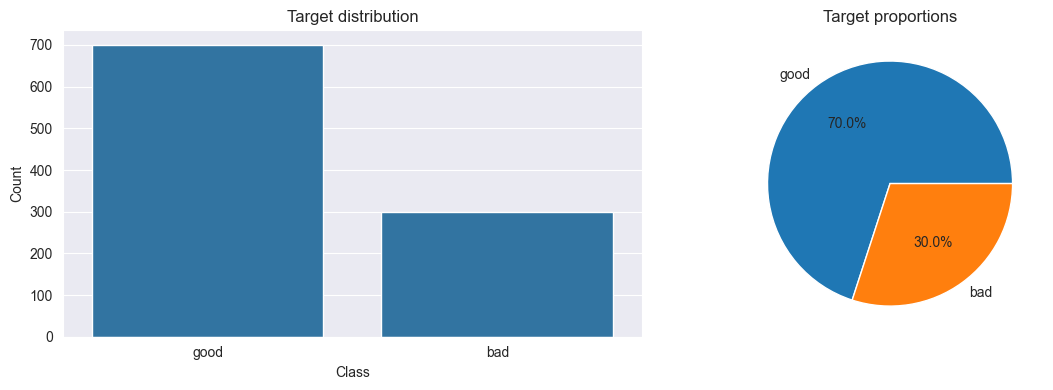

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='class', ax=axes[0])
axes[0].set_title('Target distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

class_counts.plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Target proportions')

plt.tight_layout()
plt.show()


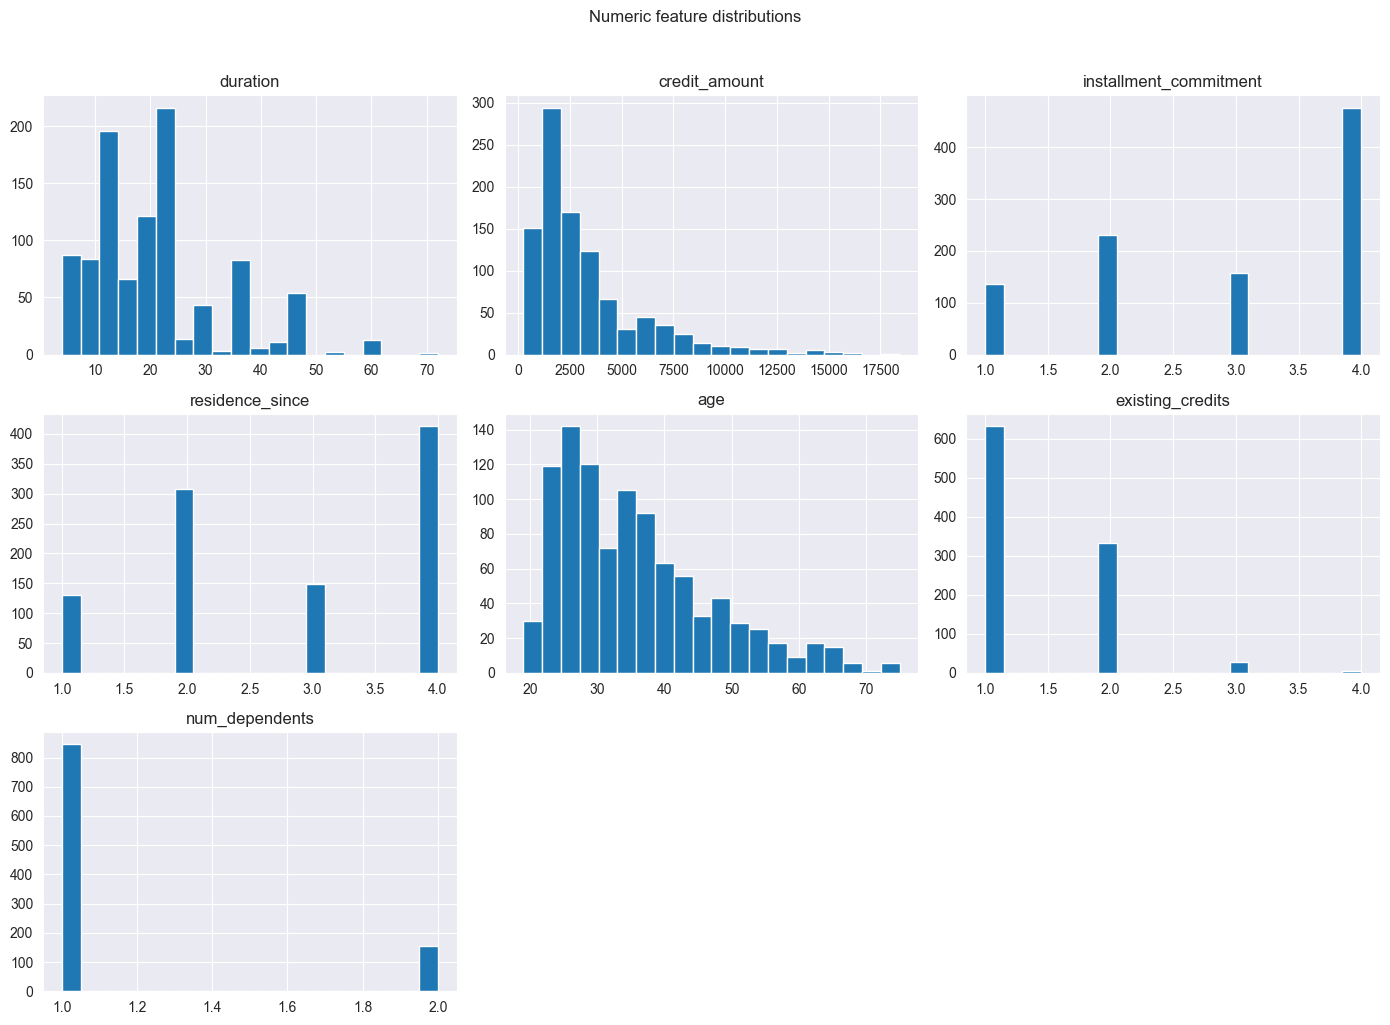

In [11]:

_ = df[num_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Numeric feature distributions', y=1.02)
plt.tight_layout()
plt.show()


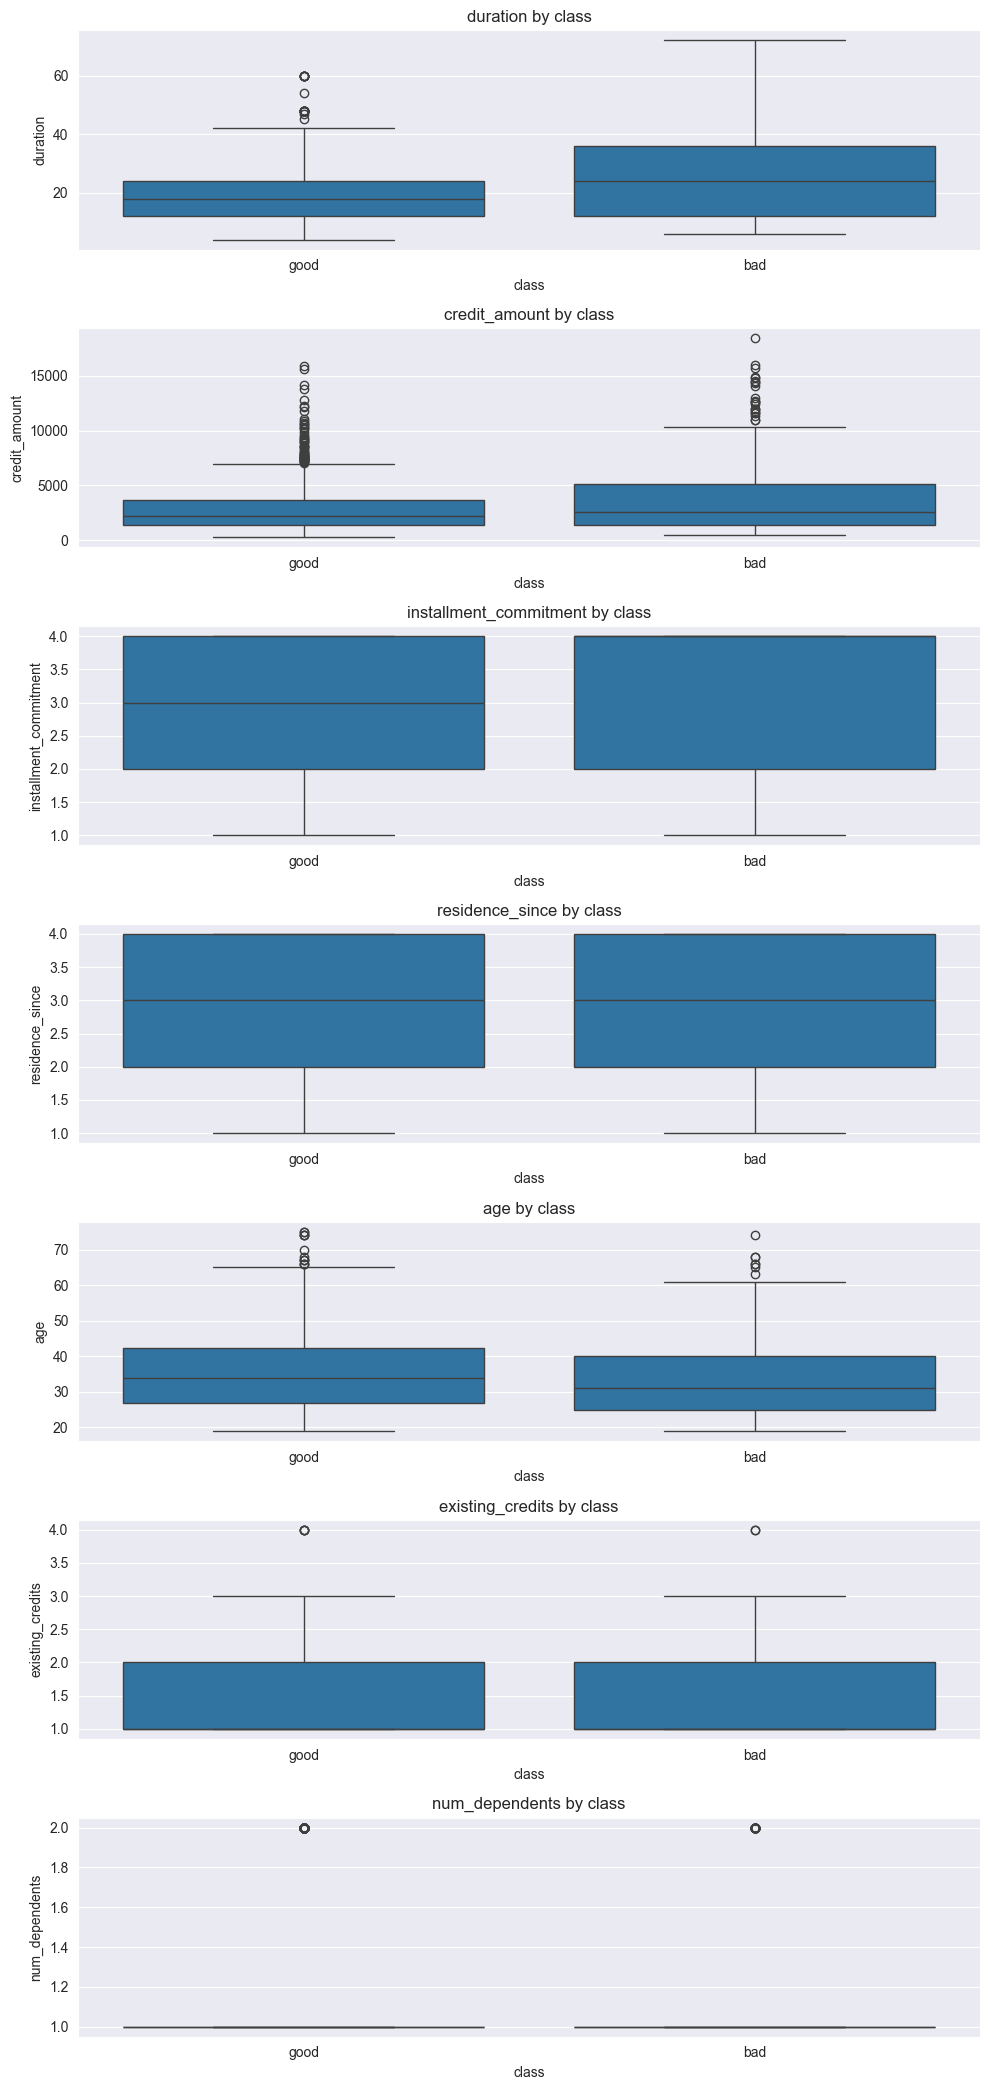

In [12]:

# Boxplots by target for numeric features
fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 3 * len(num_cols)))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='class', y=col, ax=ax)
    ax.set_title(f'{col} by class')
plt.tight_layout()
plt.show()


In [13]:

# Top category frequencies
for col in cat_cols:
    print(f'\n===== {col} =====')
    display(df[col].value_counts(dropna=False).to_frame('count'))



===== checking_status =====


,count
checking_status,
no checking,394
<0,274
0<=X<200,269
>=200,63



===== credit_history =====


,count
credit_history,
existing paid,530
critical/other existing credit,293
delayed previously,88
all paid,49
no credits/all paid,40



===== purpose =====


...

,count
job,
skilled,630
unskilled resident,200
high qualif/self emp/mgmt,148
unemp/unskilled non res,22



===== own_telephone =====


,count
own_telephone,
none,596
yes,404



===== foreign_worker =====


,count
foreign_worker,
yes,963
no,37


In [14]:

# Target rate by category: P(bad | category)
for col in cat_cols:
    summary = (
        df.groupby(col)['target']
          .agg(['count', 'mean'])
          .rename(columns={'mean': 'bad_rate'})
          .sort_values(['bad_rate', 'count'], ascending=[False, False])
    )
    print(f'\n===== Target rate by {col} =====')
    display(summary)



===== Target rate by checking_status =====


,count,bad_rate
checking_status,,
<0,274,0.492701
0<=X<200,269,0.390335
>=200,63,0.222222
no checking,394,0.116751



===== Target rate by credit_history =====


,count,bad_rate
credit_history,,
no credits/all paid,40,0.625000
all paid,49,0.571429
existing paid,530,0.318868
delayed previously,88,0.318182
critical/other existing credit,293,0.170648



===== Target rate by purpose =====


...

,count,bad_rate
job,,
high qualif/self emp/mgmt,148,0.344595
unemp/unskilled non res,22,0.318182
skilled,630,0.295238
unskilled resident,200,0.280000



===== Target rate by own_telephone =====


,count,bad_rate
own_telephone,,
none,596,0.313758
yes,404,0.279703



===== Target rate by foreign_worker =====


,count,bad_rate
foreign_worker,,
yes,963,0.307373
no,37,0.108108


In [15]:
X = df.drop(columns=['class', 'target'])
y = df['target']


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# second: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:  ', X_val.shape, y_val.shape)
print('Test shape: ', X_test.shape, y_test.shape)

print('Train target ratio:', y_train.mean().round(3))
print('Val target ratio:  ', y_val.mean().round(3))
print('Test target ratio: ', y_test.mean().round(3))

Train shape: (700, 20) (700,)
Val shape:   (150, 20) (150,)
Test shape:  (150, 20) (150,)
Train target ratio: 0.3
Val target ratio:   0.3
Test target ratio:  0.3


In [16]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_processed = preprocessor.transform(X_val).astype(np.float32)
X_test_processed = preprocessor.transform(X_test).astype(np.float32)

print('Processed train shape:', X_train_processed.shape)
print('Processed val shape:  ', X_val_processed.shape)
print('Processed test shape: ', X_test_processed.shape)


Processed train shape: (700, 61)
Processed val shape:   (150, 61)
Processed test shape:  (150, 61)


In [17]:

def make_loader(X_array, y_series, batch_size=64, shuffle=False):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.to_numpy().reshape(-1, 1), dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [18]:

train_loader = make_loader(X_train_processed, y_train, batch_size=config["batch_size_train"], shuffle=True)
val_loader = make_loader(X_val_processed, y_val, batch_size=config["batch_size_test"], shuffle=False)
test_loader = make_loader(X_test_processed, y_test, batch_size=config["batch_size_test"], shuffle=False)


In [19]:

def predict_probabilities(model, loader, criterion=None):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)

            if criterion is not None:
                loss = criterion(logits, yb)
                total_loss += loss.item() * len(xb)
                total_samples += len(xb)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    probs = np.vstack(all_probs).ravel()
    targets = np.vstack(all_targets).ravel().astype(int)
    avg_loss = total_loss / total_samples if total_samples > 0 else None
    return probs, targets, avg_loss

In [20]:


def compute_metrics(y_true, y_prob):
    threshold = config['threshold']
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        'threshold': float(threshold),
        'recall_bad': recall_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_prob),
        'cost_total': int(fp * 1 + fn * 5),
        'cost_per_sample': (fp * 1 + fn * 5) / len(y_true),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    return metrics



In [21]:

class CreditMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64)):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)




model = CreditMLP(
    input_dim=X_train_processed.shape[1],
    hidden_dims=tuple(config['hidden_dims']),
).to(device)


num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())
pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay'],
)

print('pos_weight:', pos_weight_value)
print(model)


pos_weight: 2.3333333333333335
CreditMLP(
  (network): Sequential(
    (0): Linear(in_features=61, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [22]:
# os.environ["WANDB__SERVICE_WAIT"] = "300"
# os.environ["WANDB_INIT_TIMEOUT"] = "300"
# import wandb
# 
# # wandb.login()
# 
# 
# run = wandb.init(
#     entity="lui-vitarius-slovak-university-of-technology",
#     project="NSIETE_credit",
#     config=config,
#     settings=wandb.Settings(
#         init_timeout=300,
#     ),
#     mode="offline",
# )
# 
# run_config = dict(wandb.config)
# wandb.summary['run_config'] = run_config
# 
# print('W&B config for this run:')
# display(pd.DataFrame([run_config]))


In [23]:

history = []
best_state = None
best_val_cost = np.inf
best_val_metrics = None

for epoch in range(1, config['epochs'] + 1):
    model.train()
    running_loss = 0.0
    running_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(xb)
        running_samples += len(xb)

    train_loss = running_loss / running_samples

    train_prob, train_true, train_eval_loss = predict_probabilities(model, train_loader, criterion)
    val_prob, val_true, val_eval_loss = predict_probabilities(model, val_loader, criterion)


    train_metrics = compute_metrics(train_true, train_prob)
    val_metrics = compute_metrics(val_true, val_prob)

    row = {
        'epoch': epoch,
        'train_loss': train_eval_loss,
        'val_loss': val_eval_loss,
        'train_cost_per_sample': train_metrics['cost_per_sample'],
        'train_recall_bad': train_metrics['recall_bad'],
        'train_pr_auc': train_metrics['pr_auc'],
        'val_cost_per_sample': val_metrics['cost_per_sample'],
        'val_recall_bad': val_metrics['recall_bad'],
        'val_pr_auc': val_metrics['pr_auc'],
        'val_fp': val_metrics['fp'],
        'val_fn': val_metrics['fn'],
        'val_tp': val_metrics['tp'],
        'val_tn': val_metrics['tn'],
    }
    history.append(row)
    # wandb.log(row)

    improved = val_metrics['cost_total'] < best_val_cost
    if improved:
        best_val_cost = val_metrics['cost_total']
        best_val_metrics = val_metrics.copy()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_eval_loss:.4f} | "
        f"val_loss={val_eval_loss:.4f} | "
        f"val_cost={val_metrics['cost_total']} | "
        f"val_recall_bad={val_metrics['recall_bad']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
    )

# Restore best model
model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df.tail())
print('Best validation metrics:', best_val_metrics)


Epoch 001 | train_loss=0.9469 | val_loss=0.9537 | val_cost=101 | val_recall_bad=0.7556 | val_pr_auc=0.5366 | 
Epoch 002 | train_loss=0.9082 | val_loss=0.9191 | val_cost=110 | val_recall_bad=0.6222 | val_pr_auc=0.5907 | 
Epoch 003 | train_loss=0.8470 | val_loss=0.8702 | val_cost=95 | val_recall_bad=0.7111 | val_pr_auc=0.5956 | 
Epoch 004 | train_loss=0.7770 | val_loss=0.8201 | val_cost=89 | val_recall_bad=0.8000 | val_pr_auc=0.5922 | 
Epoch 005 | train_loss=0.7159 | val_loss=0.7766 | val_cost=91 | val_recall_bad=0.7333 | val_pr_auc=0.6104 | 
Epoch 006 | train_loss=0.6808 | val_loss=0.7732 | val_cost=94 | val_recall_bad=0.7556 | val_pr_auc=0.6199 | 
Epoch 007 | train_loss=0.6594 | val_loss=0.7737 | val_cost=86 | val_recall_bad=0.7778 | val_pr_auc=0.6237 | 
Epoch 008 | train_loss=0.6423 | val_loss=0.7837 | val_cost=90 | val_recall_bad=0.7778 | val_pr_auc=0.6247 | 
Epoch 009 | train_loss=0.6301 | val_loss=0.7945 | val_cost=114 | val_recall_bad=0.6222 | val_pr_auc=0.6161 | 
Epoch 010 | trai

,epoch,train_loss,val_loss,train_cost_per_sample,train_recall_bad,train_pr_auc,val_cost_per_sample,val_recall_bad,val_pr_auc,val_fp,val_fn,val_tp,val_tn
75,76,0.004848,2.085601,0.0,1.0,1.0,0.666667,0.666667,0.662049,25,15,30,80
76,77,0.004669,2.092774,0.0,1.0,1.0,0.633333,0.688889,0.662298,25,14,31,80
77,78,0.004483,2.107731,0.0,1.0,1.0,0.633333,0.688889,0.662249,25,14,31,80
78,79,0.004342,2.119997,0.0,1.0,1.0,0.633333,0.688889,0.660916,25,14,31,80
79,80,0.004174,2.134752,0.0,1.0,1.0,0.666667,0.666667,0.663151,25,15,30,80


Best validation metrics: {'threshold': 0.5, 'recall_bad': 0.8222222222222222, 'pr_auc': 0.6258855150522615, 'cost_total': 75, 'cost_per_sample': np.float64(0.5), 'tn': 70, 'fp': 35, 'fn': 8, 'tp': 37}


In [24]:

test_prob, test_true, test_loss = predict_probabilities(model, test_loader, criterion)
test_metrics = compute_metrics(test_true, test_prob)

print('Test loss:', round(test_loss, 4))
print('Test metrics:')
for k in ['cost_per_sample', 'recall_bad', 'pr_auc', 'fp', 'fn', 'tp', 'tn']:
    v = test_metrics[k]
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

# wandb.summary.update({
#     'test_loss': float(test_loss),
#     'test_cost_per_sample': float(test_metrics['cost_per_sample']),
#     'test_recall_bad': float(test_metrics['recall_bad']),
#     'test_pr_auc': float(test_metrics['pr_auc']),
#     'test_fp': int(test_metrics['fp']),
#     'test_fn': int(test_metrics['fn']),
#     'test_tp': int(test_metrics['tp']),
#     'test_tn': int(test_metrics['tn']),
# })
# 
# wandb.summary['pos_weight'] = pos_weight_value


Test loss: 0.7301
Test metrics:
  cost_per_sample: 0.5267
  recall_bad: 0.7556
  pr_auc: 0.7204
  fp: 24
  fn: 11
  tp: 34
  tn: 81


,pred_good(0),pred_bad(1)
actual_good(0),81,24
actual_bad(1),11,34


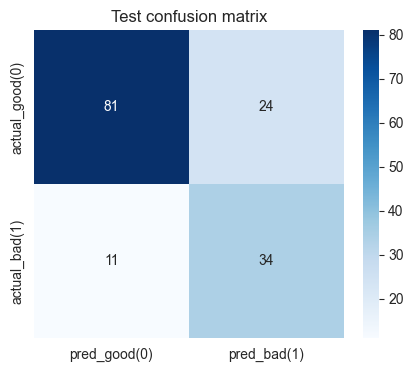

In [25]:

# Confusion matrix
cm = confusion_matrix(test_true, (test_prob >= config['threshold']).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['actual_good(0)', 'actual_bad(1)'], columns=['pred_good(0)', 'pred_bad(1)'])
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Test confusion matrix')
plt.show()


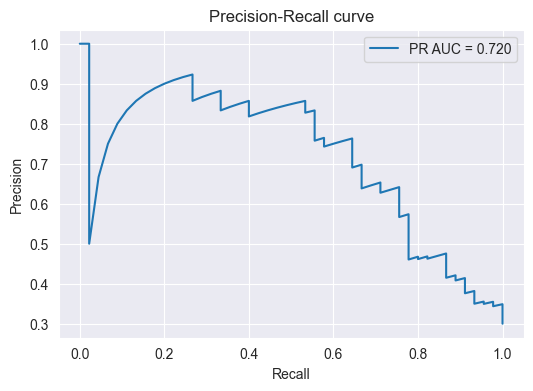

In [26]:

precision, recall, _ = precision_recall_curve(test_true, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR AUC = {test_metrics["pr_auc"]:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()


In [27]:

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'credit_mlp_best.pt'
history_path = artifacts_dir / 'training_history.csv'
metadata_path = artifacts_dir / 'experiment_metadata.json'

torch.save(model.state_dict(), model_path)
history_df.to_csv(history_path, index=False)

metadata = {
    'run_config': config,
    'pos_weight': float(pos_weight_value),
    'input_dim': int(X_train_processed.shape[1]),
    'num_train': int(len(X_train)),
    'num_val': int(len(X_val)),
    'num_test': int(len(X_test)),
    'test_metrics': {
        k: float(v) if isinstance(v, (np.floating, float)) else int(v)
        for k, v in test_metrics.items()
    },
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
print(' -', model_path)
print(' -', history_path)
print(' -', metadata_path)


Saved:
 - artifacts\credit_mlp_best.pt
 - artifacts\training_history.csv
 - artifacts\experiment_metadata.json
